In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy.stats import median_abs_deviation

In [2]:
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)

plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'DejaVu Sans'],
    'figure.titlesize': 16,
    'axes.titlesize': 16,
    'axes.labelsize': 12,

    'axes.titleweight': 'bold',
    'axes.labelweight': 'bold',

    'legend.frameon': False,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.axisbelow': True
})

In [3]:
def format_plot(ax, title, xlabel, ylabel, horizontal=False):

    ax.set_title(title, pad=20)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)

    if horizontal:
        ax.grid(axis='x', linestyle='--', alpha=0.5)
        ax.grid(axis='y', visible=False)
    else:
        ax.grid(axis='y', linestyle='--', alpha=0.5)
        ax.grid(axis='x', visible=False)

In [4]:
filePath = '../Dataset/UCI_Gallstone_Dataset.csv'
df = pd.read_csv(filePath)

In [5]:
def get_clean_mask(data, threshold=3.5):
    """
    Apply Iglewicz and Hoaglin's robust outlier detection.
    Returns: Boolean mask (True = Valid, False = Outlier)
    """
    median = np.median(data)
    mad = median_abs_deviation(data, scale='normal')
    modified_z_score = 0.6745 * (data - median) / mad
    return modified_z_score.abs() < threshold

In [6]:
df_bioimpedance = df[[
    'Weight',
    'Total Body Water (TBW)',         # Measured in kg
    'Extracellular Water (ECW)',      # Measured in kg
    'Intracellular Water (ICW)',      # Measured in kg
    'Extracellular Fluid/Total Body Water (ECF/TBW)', # Derived Fluid Ratio
    'Total Body Fat Ratio (TBFR) (%)',# Percentage of total mass
    'Lean Mass (LM) (%)',             # Percentage of fat-free mass
    'Body Protein Content (Protein) (%)', # Protein composition percentage
    'Visceral Fat Rating (VFR)',      # Corresponds to "Visceral Adiposity Index" in text [cite: 61]
    'Bone Mass (BM)',                 # Measured in kg
    'Muscle Mass (MM)',               # Measured in kg
    'Obesity (%)',                    # Degree of obesity percentage
    'Total Fat Content (TFC)',        # Measured in kg
    'Visceral Fat Area (VFA)',        # Measured in kg
    'Visceral Muscle Area (VMA) (Kg)' # Measured in kg
]].copy()

df_bioimpedance

,Weight,Total Body Water (TBW),Extracellular Water (ECW),Intracellular Water (ICW),Extracellular Fluid/Total Body Water (ECF/TBW),Total Body Fat Ratio (TBFR) (%),Lean Mass (LM) (%),Body Protein Content (Protein) (%),Visceral Fat Rating (VFR),Bone Mass (BM),Muscle Mass (MM),Obesity (%),Total Fat Content (TFC),Visceral Fat Area (VFA),Visceral Muscle Area (VMA) (Kg)
0,92.8,52.9,21.2,31.7,40.00,19.20,80.84,18.88,9,3.7,71.4,23.40,17.8,10.60,39.7
1,94.5,43.1,19.5,23.6,45.00,32.80,67.20,16.68,15,3.2,60.3,38.80,31.0,18.40,32.7
2,91.1,47.2,20.1,27.1,43.00,27.30,72.67,16.35,15,3.3,62.9,41.70,24.9,16.20,34.0
3,67.7,41.4,17.0,24.4,41.00,15.80,84.19,16.90,6,2.9,54.1,9.00,10.7,6.50,29.2
4,89.6,51.4,20.0,31.4,39.00,20.00,80.02,16.81,8,3.5,68.2,28.60,17.9,10.40,37.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
314,88.8,47.6,20.0,28.0,42.01,24.66,75.23,16.13,11,3.3,63.5,14.39,21.9,13.58,34.2
315,53.4,29.3,12.3,17.0,42.00,23.60,76.40,15.96,2,2.1,38.7,1.50,12.6,5.10,22.2
316,96.6,49.2,21.0,28.2,43.00,28.80,71.22,15.87,16,3.4,65.4,48.40,27.8,17.10,35.6
317,88.4,50.2,19.9,30.3,40.00,21.10,78.85,16.30,8,3.4,66.3,28.30,18.7,11.00,36.1


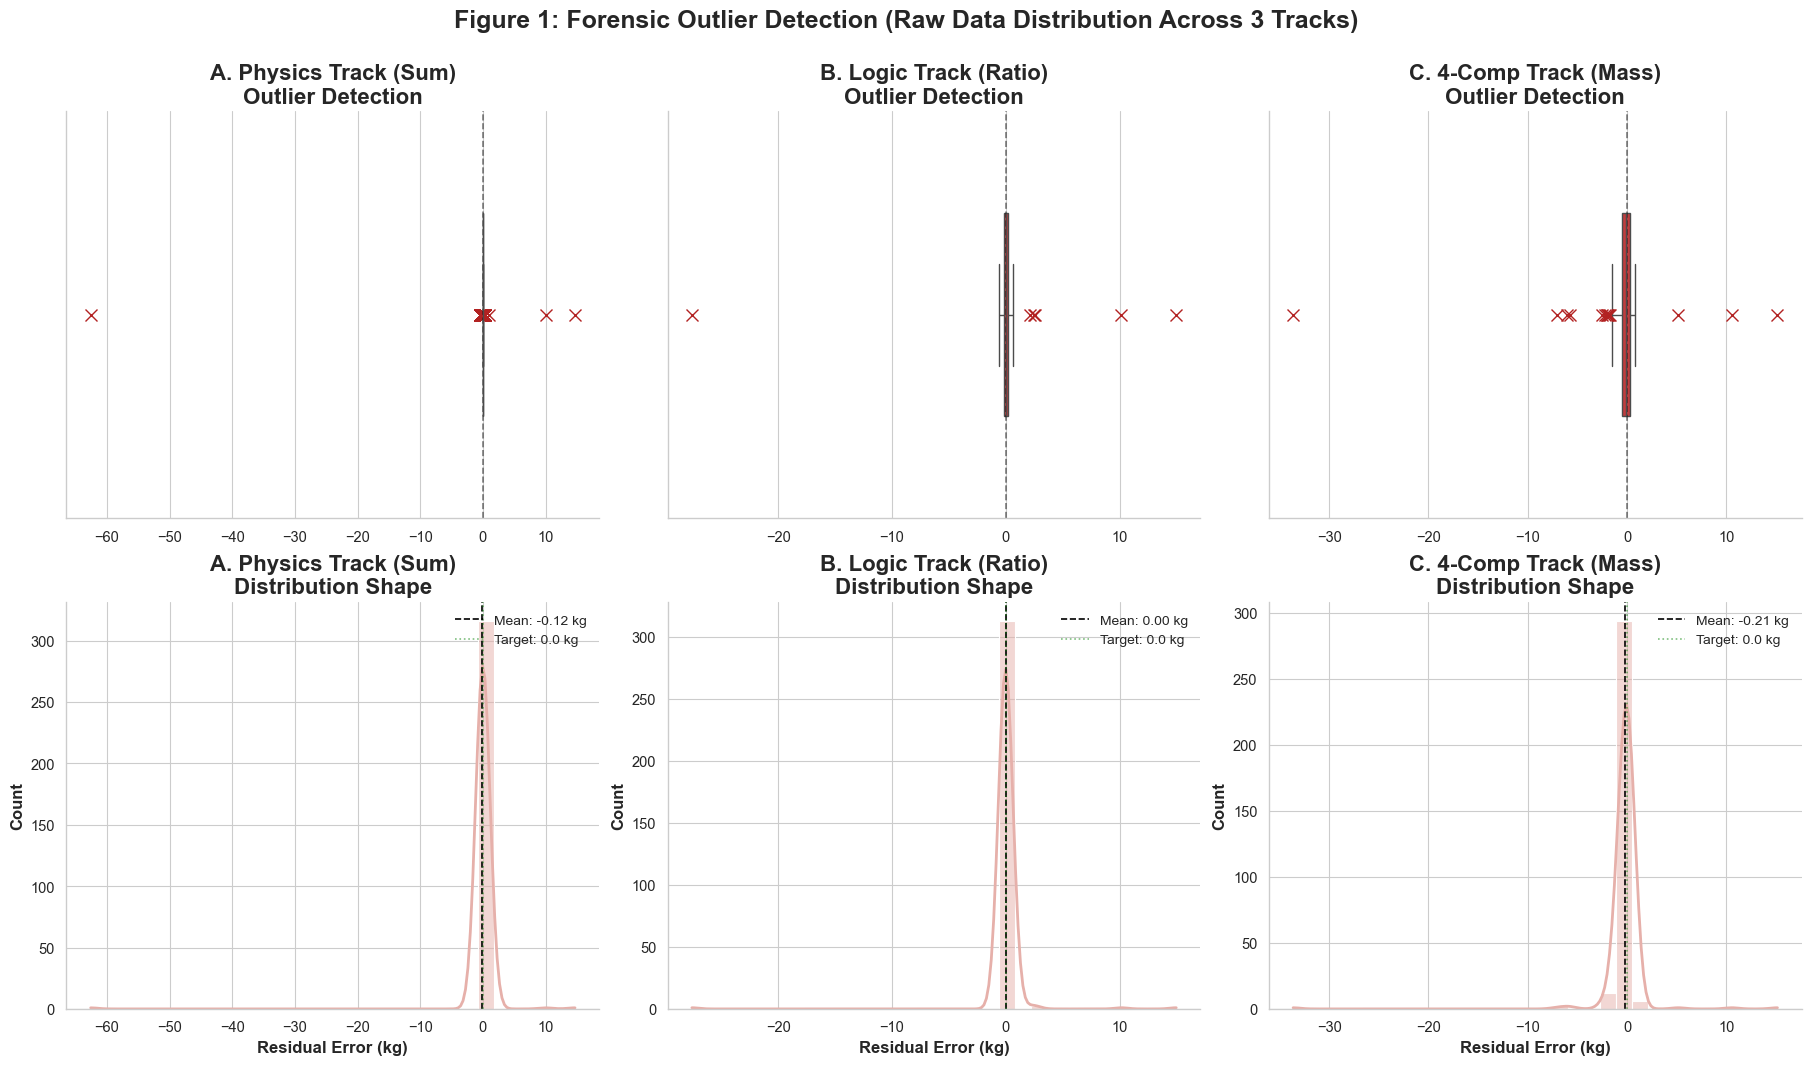

In [7]:
# --- 1. 计算三条轨道的残差 (Residuals) ---

# Track A: Physics (Summation) | TBW - (ECW + ICW)
df_bioimpedance['Calc_Sum'] = df_bioimpedance['Extracellular Water (ECW)'] + df_bioimpedance['Intracellular Water (ICW)']
df_bioimpedance['Res_Physics'] = df_bioimpedance['Total Body Water (TBW)'] - df_bioimpedance['Calc_Sum']

# Track B: Logic (Ratio) | TBW - ECW / (Ratio/100)
df_bioimpedance['Calc_Ratio_TBW'] = df_bioimpedance['Extracellular Water (ECW)'] / (df_bioimpedance['Extracellular Fluid/Total Body Water (ECF/TBW)'] / 100)
df_bioimpedance['Res_Logic'] = df_bioimpedance['Total Body Water (TBW)'] - df_bioimpedance['Calc_Ratio_TBW']

# Track C: 4-Component Model | TBW - (Weight - Fat - Bone - Protein - 0.94)
epsilon = 0.94
calc_fat = df_bioimpedance['Weight'] * (df_bioimpedance['Total Body Fat Ratio (TBFR) (%)'] / 100)
calc_prot = df_bioimpedance['Weight'] * (df_bioimpedance['Body Protein Content (Protein) (%)'] / 100)
df_bioimpedance['Calc_4Comp_TBW'] = df_bioimpedance['Weight'] - calc_fat - df_bioimpedance['Bone Mass (BM)'] - calc_prot - epsilon
df_bioimpedance['Res_4Comp'] = df_bioimpedance['Total Body Water (TBW)'] - df_bioimpedance['Calc_4Comp_TBW']

# --- 2. 绘图 (Figure 1: Distribution Analysis - CLEAN VERSION) ---
fig, axes = plt.subplots(2, 3, figsize=(18, 10), constrained_layout=True)

tracks = [
    ('A. Physics Track (Sum)', 'Res_Physics'),
    ('B. Logic Track (Ratio)', 'Res_Logic'),
    ('C. 4-Comp Track (Mass)', 'Res_4Comp')
]

for i, (title, col) in enumerate(tracks):
    data = df_bioimpedance[col]

    # -----------------------------
    # Row 1: Boxplot (侦测)
    # -----------------------------
    # 纯净版：无 ID 标注
    sns.boxplot(x=data, ax=axes[0, i], color='tab:red', width=0.5,
                flierprops={"marker": "x", "markeredgecolor": "firebrick", "markersize": 8})

    axes[0, i].set_title(f"{title}\nOutlier Detection", fontweight='bold')
    axes[0, i].set_xlabel("")
    axes[0, i].axvline(0, color='black', linestyle='--', alpha=0.5)

    # -----------------------------
    # Row 2: Histogram (分布形态)
    # -----------------------------
    sns.histplot(x=data, ax=axes[1, i], color='#E6B0AA', bins=30, kde=True, line_kws={'linewidth': 2, 'color': 'firebrick'})

    mean_val = data.mean()
    axes[1, i].axvline(mean_val, color='black', linestyle='--', label=f'Mean: {mean_val:.2f} kg')
    axes[1, i].axvline(0, color='green', linestyle=':', alpha=0.5, label='Target: 0.0 kg')

    axes[1, i].set_title(f"{title}\nDistribution Shape", fontweight='bold')
    axes[1, i].set_xlabel("Residual Error (kg)")
    axes[1, i].legend(loc='upper right', fontsize=10)

plt.suptitle("Figure 1: Forensic Outlier Detection (Raw Data Distribution Across 3 Tracks)", y=1.05, fontsize=18, fontweight='bold')
plt.show()

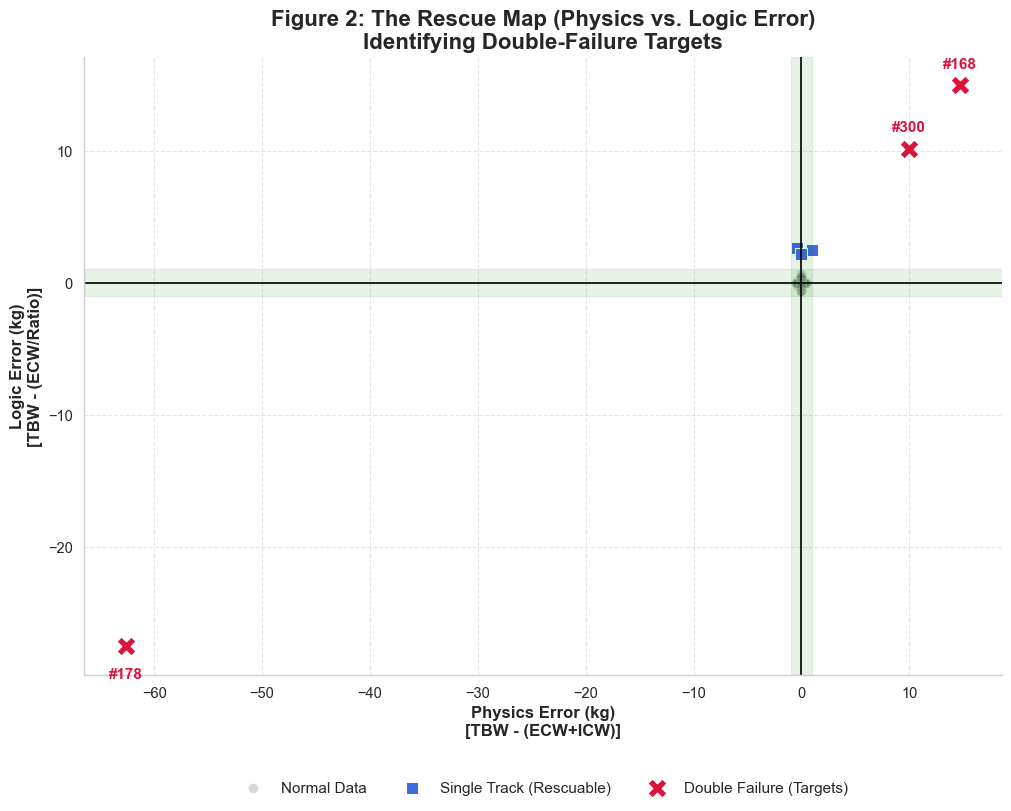

In [8]:
# --- 2. Figure 2: The Rescue Map (Legend at BOTTOM) ---
threshold = 1.0

# Mask 定义
mask_good = (df_bioimpedance['Res_Physics'].abs() <= threshold) & (df_bioimpedance['Res_Logic'].abs() <= threshold)
mask_axis = ((df_bioimpedance['Res_Physics'].abs() <= threshold) & (df_bioimpedance['Res_Logic'].abs() > threshold)) | \
            ((df_bioimpedance['Res_Physics'].abs() > threshold) & (df_bioimpedance['Res_Logic'].abs() <= threshold))
mask_outer = (df_bioimpedance['Res_Physics'].abs() > threshold) & (df_bioimpedance['Res_Logic'].abs() > threshold)

# 绘图
fig2, ax2 = plt.subplots(figsize=(10, 8), constrained_layout=True)

# 1. 绘制散点
sns.scatterplot(data=df_bioimpedance[mask_good], x='Res_Physics', y='Res_Logic',
                color='gray', alpha=0.3, s=50, label='Normal Data', ax=ax2)
sns.scatterplot(data=df_bioimpedance[mask_axis], x='Res_Physics', y='Res_Logic',
                color='royalblue', s=80, marker='s', label='Single Track (Rescuable)', ax=ax2)
sns.scatterplot(data=df_bioimpedance[mask_outer], x='Res_Physics', y='Res_Logic',
                color='crimson', s=200, marker='X', label='Double Failure (Targets)', ax=ax2)

# 2. 绘制绿色区域
ax2.axhspan(-threshold, threshold, color='green', alpha=0.1)
ax2.axvspan(-threshold, threshold, color='green', alpha=0.1)
ax2.axhline(0, color='black', linestyle='-')
ax2.axvline(0, color='black', linestyle='-')

# 3. 简单的 ID 标注 (放在点上方/下方)
for idx, row in df_bioimpedance[mask_outer].iterrows():
    xytext_offset = (0, 10) if row['Res_Logic'] >= 0 else (0, -15)
    va_align = 'bottom' if row['Res_Logic'] >= 0 else 'top'

    ax2.annotate(f"#{idx}",
                 xy=(row['Res_Physics'], row['Res_Logic']),
                 xytext=xytext_offset,
                 textcoords='offset points',
                 color='crimson', fontweight='bold', fontsize=11,
                 ha='center', va=va_align)

# 4. 标题与坐标轴
ax2.set_title("Figure 2: The Rescue Map (Physics vs. Logic Error)\nIdentifying Double-Failure Targets",
              fontweight='bold', fontsize=16)
ax2.set_xlabel("Physics Error (kg)\n[TBW - (ECW+ICW)]", fontweight='bold')
ax2.set_ylabel("Logic Error (kg)\n[TBW - (ECW/Ratio)]", fontweight='bold')
ax2.grid(True, linestyle='--', alpha=0.5)

# --- 关键修复：图例移至底部 (Bottom) ---
# loc='upper center': 图例自身的参考点是它的“上边缘中心”
# bbox_to_anchor=(0.5, -0.15): 放置在 X轴下方 15% 的位置
# ncol=3: 横向排列
ax2.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15),
           ncol=3, frameon=False, fontsize=11)

plt.show()

In [9]:
df_ba = df.copy() # 创建用于 Bland-Altman 分析的副本

# --- 1. 基础指标计算 (用于分类) ---
# Track A: Physics (Sum)
df_ba['Calc_Sum'] = df_ba['Extracellular Water (ECW)'] + df_ba['Intracellular Water (ICW)']
df_ba['Res_Physics'] = df_ba['Total Body Water (TBW)'] - df_ba['Calc_Sum']

# Track B: Logic (Ratio)
df_ba['Calc_Ratio_TBW'] = df_ba['Extracellular Water (ECW)'] / (df_ba['Extracellular Fluid/Total Body Water (ECF/TBW)'] / 100)
df_ba['Res_Logic'] = df_ba['Total Body Water (TBW)'] - df_ba['Calc_Ratio_TBW']

# Track C: Gold Standard (4-Component Model)
# 独立的验证标准：TBW = Weight - Fat - Bone - Protein - 0.94
epsilon = 0.94
calc_fat = df_ba['Weight'] * (df_ba['Total Body Fat Ratio (TBFR) (%)'] / 100)
calc_prot = df_ba['Weight'] * (df_ba['Body Protein Content (Protein) (%)'] / 100)
df_ba['Gold_Standard_TBW'] = df_ba['Weight'] - calc_fat - df_ba['Bone Mass (BM)'] - calc_prot - epsilon

# --- 2. 定义异常状态与修复逻辑 ---
threshold = 1.0

# 状态分类掩码
mask_double = (df_ba['Res_Physics'].abs() > threshold) & (df_ba['Res_Logic'].abs() > threshold) # Type 1
mask_logic_only = (df_ba['Res_Logic'].abs() > threshold) & (df_ba['Res_Physics'].abs() <= threshold) # Type 2
mask_physics_only = (df_ba['Res_Physics'].abs() > threshold) & (df_ba['Res_Logic'].abs() <= threshold) # Type 3
mask_good = ~(mask_double | mask_logic_only | mask_physics_only)

# 标记数据状态 (用于绘图颜色)
df_ba['Data Status'] = 'Original (Verified)'
df_ba.loc[mask_double | mask_logic_only | mask_physics_only, 'Data Status'] = 'Repaired (Was Outlier)'

# --- 3. 执行三路修复 (Surgical Repair) ---
# 初始化 Final 列为原始值
df_ba['TBW_Final'] = df_ba['Total Body Water (TBW)']

# 方案 1: Logic & Physics Error -> 使用 Ratio 倒推
# 公式: TBW = ECW / Ratio%
df_ba.loc[mask_double, 'TBW_Final'] = df_ba.loc[mask_double, 'Calc_Ratio_TBW']

# 方案 2: Logic Error Only -> 使用 Sum (ECW+ICW)
# 公式: TBW = ICW + ECW
df_ba.loc[mask_logic_only, 'TBW_Final'] = df_ba.loc[mask_logic_only, 'Calc_Sum']

# 方案 3: Physics Error Only -> 使用 Ratio 倒推
# 公式: TBW = ECW / Ratio%
df_ba.loc[mask_physics_only, 'TBW_Final'] = df_ba.loc[mask_physics_only, 'Calc_Ratio_TBW']

# --- 4. 准备 Bland-Altman 数据 ---
# 左图数据 (修复前 vs 金标准)
df_ba['Mean_Raw'] = (df_ba['Total Body Water (TBW)'] + df_ba['Gold_Standard_TBW']) / 2
df_ba['Diff_Raw'] = df_ba['Total Body Water (TBW)'] - df_ba['Gold_Standard_TBW']

# 右图数据 (修复后 vs 金标准)
df_ba['Mean_Final'] = (df_ba['TBW_Final'] + df_ba['Gold_Standard_TBW']) / 2
df_ba['Diff_Final'] = df_ba['TBW_Final'] - df_ba['Gold_Standard_TBW']

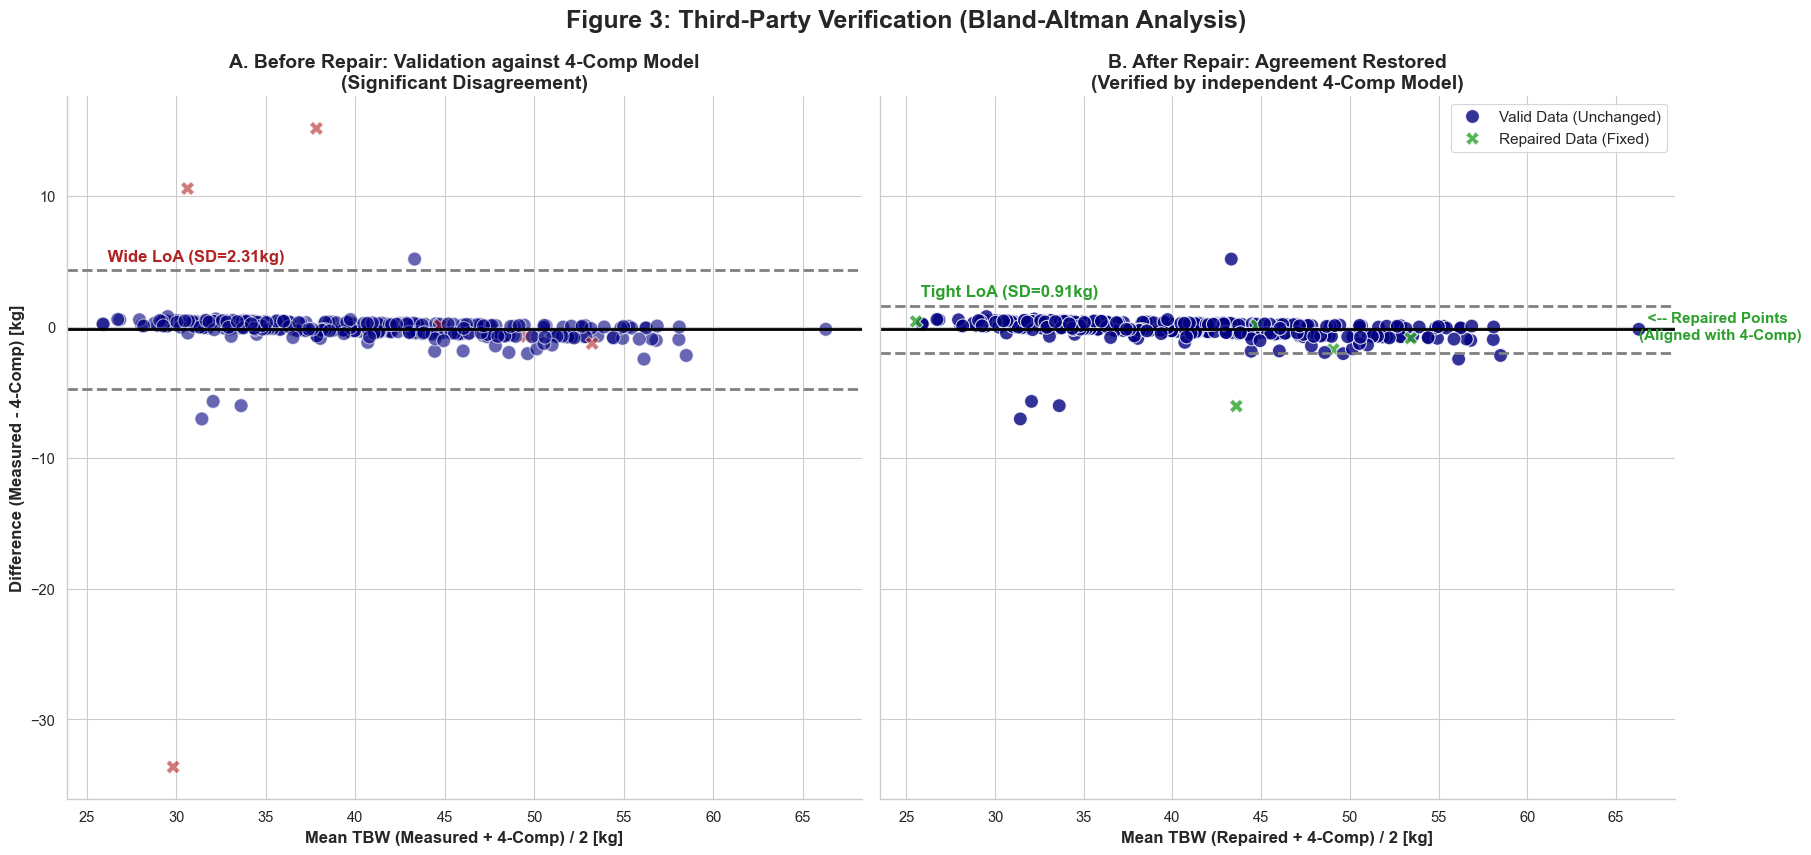

In [10]:
# ==============================================================================
# FIGURE: Bland-Altman Comparison (3rd Party Verification via 4-Comp Model)
# ==============================================================================

# 设置画布：1行2列
fig, axes = plt.subplots(1, 2, figsize=(18, 8), sharey=True, constrained_layout=True)

# 颜色映射
palette_raw = {'Original (Verified)': 'navy', 'Repaired (Was Outlier)': 'firebrick'}
palette_fix = {'Original (Verified)': 'navy', 'Repaired (Was Outlier)': 'tab:green'}
markers = {'Original (Verified)': 'o', 'Repaired (Was Outlier)': 'X'}

# ------------------------------------------
# 左图：修复前 (Before Repair)
# ------------------------------------------
ax1 = axes[0]
sns.scatterplot(data=df_ba, x='Mean_Raw', y='Diff_Raw',
                hue='Data Status', palette=palette_raw, style='Data Status', markers=markers,
                s=100, alpha=0.6, ax=ax1, legend=False)

# 统计线 (基于原始数据)
mean_raw = df_ba['Diff_Raw'].mean()
sd_raw = df_ba['Diff_Raw'].std()
ax1.axhline(mean_raw, color='black', ls='-', lw=2, label='Mean Bias')
ax1.axhline(mean_raw + 1.96*sd_raw, color='gray', ls='--', lw=2, label='1.96 SD')
ax1.axhline(mean_raw - 1.96*sd_raw, color='gray', ls='--', lw=2)

# 标注
ax1.set_title("A. Before Repair: Validation against 4-Comp Model\n(Significant Disagreement)", fontweight='bold', fontsize=14)
ax1.set_xlabel("Mean TBW (Measured + 4-Comp) / 2 [kg]")
ax1.set_ylabel("Difference (Measured - 4-Comp) [kg]")

# 标注极差 SD
ax1.text(df_ba['Mean_Raw'].min(), mean_raw + 1.96*sd_raw + 0.5,
         f' Wide LoA (SD={sd_raw:.2f}kg)', color='firebrick', va='bottom', fontweight='bold', fontsize=12)

# ------------------------------------------
# 右图：修复后 (After Repair)
# ------------------------------------------
ax2 = axes[1]
sns.scatterplot(data=df_ba, x='Mean_Final', y='Diff_Final',
                hue='Data Status', palette=palette_fix, style='Data Status', markers=markers,
                s=100, alpha=0.8, ax=ax2)

# 统计线 (基于修复后数据)
mean_fix = df_ba['Diff_Final'].mean()
sd_fix = df_ba['Diff_Final'].std()
ax2.axhline(mean_fix, color='black', ls='-', lw=2)
ax2.axhline(mean_fix + 1.96*sd_fix, color='gray', ls='--', lw=2)
ax2.axhline(mean_fix - 1.96*sd_fix, color='gray', ls='--', lw=2)

# 标注
ax2.set_title("B. After Repair: Agreement Restored\n(Verified by independent 4-Comp Model)", fontweight='bold', fontsize=14)
ax2.set_xlabel("Mean TBW (Repaired + 4-Comp) / 2 [kg]")

# 标注绿色修复点效果
ax2.text(df_ba['Mean_Final'].max(), 0, "  <-- Repaired Points\n(Aligned with 4-Comp)",
         color='tab:green', va='center', ha='left', fontweight='bold', fontsize=11)

# 标注收窄的 SD
ax2.text(df_ba['Mean_Final'].min(), mean_fix + 1.96*sd_fix + 0.5,
         f' Tight LoA (SD={sd_fix:.2f}kg)', color='tab:green', va='bottom', fontweight='bold', fontsize=12)

# 图例优化
handles, labels = ax2.get_legend_handles_labels()
ax2.legend(handles, ['Valid Data (Unchanged)', 'Repaired Data (Fixed)'], loc='upper right', frameon=True, fontsize=11)

plt.suptitle("Figure 3: Third-Party Verification (Bland-Altman Analysis)", y=1.05, fontsize=18, fontweight='bold')
plt.show()